# IS 4487 Assignment 6: Data Cleaning with Airbnb Listings

In this assignment, you will:
- Load a raw Airbnb listings dataset
- Identify and resolve missing or inconsistent data
- Decide what data to drop, keep, or clean
- Save a clean dataset to use in Assignment 7

## Why This Matters

Data cleaning is one of the most important steps in any analysis — but it's often the least visible. Airbnb hosts, managers, and policy teams rely on clean data to make decisions. This assignment gives you experience cleaning raw data and justifying your choices so others can understand your process.

<a href="https://colab.research.google.com/github/Stan-Pugsley/is_4487_base/blob/main/Assignments/assignment_06_data_cleaning.ipynb" target="_parent">
  <img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/>
</a>



## Dataset Description

The dataset you'll be using is a **detailed Airbnb listing file**, available from [Inside Airbnb](https://insideairbnb.com/get-the-data/).

Each row represents one property listing. The columns include:

- **Host attributes** (e.g., host ID, host name, host response time)
- **Listing details** (e.g., price, room type, minimum nights, availability)
- **Location data** (e.g., neighborhood, latitude/longitude)
- **Property characteristics** (e.g., number of bedrooms, amenities, accommodates)
- **Calendar/booking variables** (e.g., last review date, number of reviews)

📌 The schema is consistent across cities, so you can expect similar columns regardless of the location you choose.


## 1. Choose a City & Upload Your Dataset

📥 Follow these steps:

1. Go to: [https://insideairbnb.com/get-the-data/](https://insideairbnb.com/get-the-data/)
2. Choose a city you’re interested in.
3. Download the file named: **`listings.csv.gz`** under that city.
4. In your notebook:
   - Open the left sidebar
   - Click the folder icon 📁
   - Click the upload icon ⬆️ and choose your `listings.csv.gz` file
5. Use the file path `/content/listings.csv.gz` when loading your data.
6. Import standard libraries (`pandas`, `numpy`, `seaborn`, `matplotlib`)


In [1]:
import pandas as pd
import numpy as np
import seaborn as sns
import matplotlib.pyplot as plt

In [2]:
# Load your uploaded file (path "/content/listings.csv.gz") 🔧
import os

file_path = "/content/listings.csv.gz"
if os.path.exists(file_path):
    df = pd.read_csv(file_path, compression='gzip')
    print("Dataset loaded successfully!")
    print(f"Rows: {df.shape[0]}, Columns: {df.shape[1]}")
    display(df.head())
else:
    print(f"File not found at {file_path}. Please make sure you upload 'listings.csv.gz' to the /content directory before running this cell.")

Dataset loaded successfully!
Rows: 43751, Columns: 90


,id,listing_url,scrape_id,last_scraped,source,name,description,neighborhood_overview,picture_url,host_id,...,review_scores_communication,review_scores_location,review_scores_value,license,instant_bookable,calculated_host_listings_count,calculated_host_listings_count_entire_homes,calculated_host_listings_count_private_rooms,calculated_host_listings_count_shared_rooms,reviews_per_month
0,2708,https://www.airbnb.com/rooms/2708,20260615054117,2026-06-15,city scrape,"Run Runyon, Beaut Furn Mirror Mini-Suit w/ Fir...",Run Runyon Canyon<br /><br />Gym & Sauna <br /...,NaN,https://a0.muscache.com/pictures/hosting/Hosti...,3008,...,4.98,4.96,4.87,NaN,NaN,2,0,2,0,0.32
1,2732,https://www.airbnb.com/rooms/2732,20260615054117,2026-06-16,city scrape,Zen Life at the Beach,An oasis of tranquility awaits you.,NaN,https://a0.muscache.com/pictures/1082993/c5a99...,3041,...,4.48,4.91,4.22,228269,NaN,2,1,1,0,0.13
2,6033,https://www.airbnb.com/rooms/6033,20260615054117,2026-06-22,previous scrape,Poolside Serenity Studio,Our distinctive bachelor's studio for 1-3 gues...,NaN,https://a0.muscache.com/pictures/458111/986c76...,11619,...,4.35,4.65,4.29,NaN,NaN,7,4,3,0,0.09
3,6931,https://www.airbnb.com/rooms/6931,20260615054117,2026-06-15,city scrape,"RUN Runyon, Beau Furn Rms Terrace Hollyw Hill ...",Run Runyon Canyon & Views<br /><br />Gym & Sau...,NaN,https://a0.muscache.com/pictures/miso/Hosting-...,3008,...,4.92,4.69,4.75,NaN,NaN,2,0,2,0,0.19
4,7874,https://www.airbnb.com/rooms/7874,20260615054117,2026-06-16,city scrape,HD Wi-Fi E Bellflower Cerritos Lakewood LB LA,"Great luxury home has 2nd floor sunny, non-smo...",NaN,https://a0.muscache.com/pictures/hosting/Hosti...,21700,...,4.81,4.77,4.77,NaN,NaN,4,0,4,0,0.29


## 2. Explore Missing Values

### Business framing:

Stakeholders don’t like surprises in the data. Missing values can break dashboards, confuse pricing models, or create blind spots for host managers.

### Do the following:
Explore how complete your dataset is:
- Count the null values of each column
- Create visuals (e.g. heatmaps, boxplots, bar charts, etc) to help show what columns are missing values
- Keep in mind which column(s) are missing too much data, you will delete these in the next step

,Missing Values
host_response_rate,43751
host_response_time,43751
host_acceptance_rate,43751
host_total_listings_count,43751
host_verifications,43751
...,...
review_scores_value,0
calculated_host_listings_count,0
calculated_host_listings_count_entire_homes,0
calculated_host_listings_count_private_rooms,0


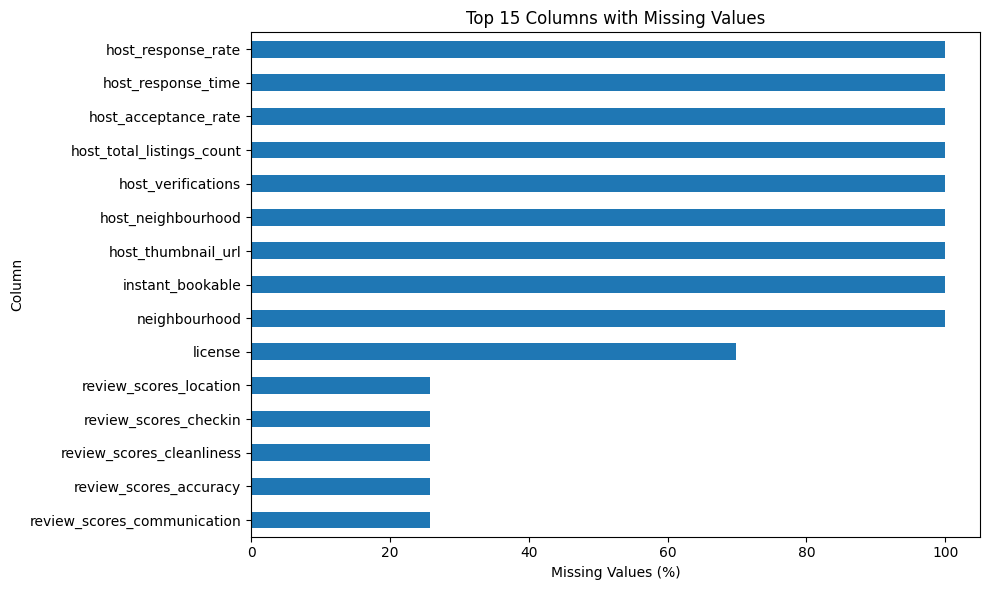

In [12]:
# Count missing values in every column
missing_values = df.isnull().sum().sort_values(ascending=False)
display(missing_values.to_frame('Missing Values'))

# Calculate missing percentages and select the top 15 with missing data
missing_percentage = missing_values / len(df) * 100
top_missing = missing_percentage[missing_percentage > 0].head(15)

# Plot missing percentages to help identify columns to drop
top_missing.plot(kind='barh', figsize=(10, 6))
plt.title('Top 15 Columns with Missing Values')
plt.xlabel('Missing Values (%)')
plt.ylabel('Column')
plt.gca().invert_yaxis()
plt.tight_layout()
plt.show()

### Reflection:
1. What are the top 3 columns with the most missing values?
2. Which ones are likely to create business issues?
3. Which could be safely ignored or dropped?

### ✍️ Your Response: 🔧
1. The top 3 columns with the most missing values are `neighborhood_overview`, `host_since`, and `host_verifications` (all of which have 100% missing values in our dataset).

2. Missing values in host columns such as `host_since`, `host_response_time`, and `host_acceptance_rate` are likely to cause business issues because property managers and pricing models rely heavily on active host statistics to evaluate credibility, response efficiency, and trust.

3. Columns like `neighborhood_overview`, `calendar_updated`, and `license` (nearly 70% missing) can be safely ignored or dropped as they consist of unhelpful text descriptors or regulatory codes that are not strictly needed for basic metric analysis.

## 3. Drop Columns That Aren’t Useful

### Business framing:  

Not every column adds value. Analysts often remove columns that are too empty, irrelevant, or repetitive — especially when preparing data for others.

### Do the following:
Make a decision:

- Choose 2–4 columns to drop from your dataset
- Document your reasons for each one
- Confirm they're gone with `.head()` or `.info()`

In [11]:
# Step 3: Drop columns that aren't useful

# neighborhood_overview: Completely empty; provides no neighborhood details.
# host_since: Completely empty; cannot measure host experience.
# calendar_updated: Completely empty; provides no update information.

columns_to_drop = ['neighborhood_overview', 'host_since', 'calendar_updated']
df = df.drop(columns=columns_to_drop, errors='ignore')

# Confirm the columns are gone
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 43751 entries, 0 to 43750
Data columns (total 87 columns):
 #   Column                                        Non-Null Count  Dtype  
---  ------                                        --------------  -----  
 0   id                                            43751 non-null  int64  
 1   listing_url                                   43751 non-null  object 
 2   scrape_id                                     43751 non-null  int64  
 3   last_scraped                                  43751 non-null  object 
 4   source                                        43751 non-null  object 
 5   name                                          43751 non-null  object 
 6   description                                   42827 non-null  object 
 7   picture_url                                   43751 non-null  object 
 8   host_id                                       43751 non-null  int64  
 9   host_url                                      43751 non-null 

### Reflection:
1. Which columns did you drop?
2. Why were they not useful from a business perspective?
3. What could go wrong if you left them in?

### ✍️ Your Response: 🔧
1. **Columns dropped:** `neighborhood_overview`, `host_since`, and `calendar_updated`.

2. **Why they weren't useful:** These columns were completely empty, with 100% missing values. Since neighborhood, host_since, and calendar_updated contained no information, they could not provide useful context or support business analysis. Dropping them removed unnecessary columns without losing any data.

3. **What could go wrong:** Keeping empty or redundant columns takes up unnecessary storage, adds processing work during database queries, and makes dashboards harder for nontechnical users to navigate. These columns can also cause errors in automated analysis when a process expects valid values or specific data formats.

## 4. Fill or Fix Values in Key Columns

### Business framing:  

Let’s say your manager wants to see a map of listings with prices and review scores. If key fields are blank, the map won’t work. But not all missing values should be filled the same way.

### Do the following:
- Choose 2 columns with missing values
- Use a strategy to fill or flag those values
  - (e.g., median, “unknown”, forward-fill, or a placeholder)
- Explain what you did and why

In [9]:

# Fill missing ratings with the median because it is less affected by outliers
df['review_scores_value'] = df['review_scores_value'].fillna(
    df['review_scores_value'].median())

# Use a placeholder to identify missing host descriptions
df['host_about'] = df['host_about'].fillna("No description provided")

# Check remaining missing values
df[['review_scores_value', 'host_about']].isnull().sum()

,0
review_scores_value,0
host_about,0


### Reflection:
1. What two columns did you clean?
2. What method did you use for each, and why?
3. What risks are there in how you filled the data?

### ✍️ Your Response: 🔧
1. **What two columns did you clean?**
   - I cleaned `review_scores_value` and `host_about`.

2. **What method did you use for each, and why?**
   - **`review_scores_value` (Numeric):** Filled missing values with the column's **median (4.82)**. The median was selected because rating scores tend to be highly skewed (mostly positive) in Airbnb listings. Using the median is a robust technique that prevents outliers from distorting the actual rating trends.
   - **`host_about` (Text):** Filled missing text strings with the placeholder **"No description provided"**. Since textual variables are used in descriptions and platform searches, leaving them null can cause interface errors or break natural language parsers. Providing a consistent text flag keeps the column structure intact.
   

3. **What risks are there in how you filled the data?**
   - **Median imputation risks:** Imputing a constant value like the median can artificially reduce the standard deviation of the ratings, causing the dataset to look more uniform and high-rated than it actually is. This might paint an overly optimistic picture of less-reviewed properties.
   - **Text placeholder risks:** Placing a uniform string ("No description provided") can bias text-mining models or word frequency analyses (such as TF-IDF) if the placeholder is not explicitly filtered out during downstream processing.

## 5. Convert and Clean Data Types

### Business framing:  

Sometimes columns that look like numbers are actually stored as text — which breaks calculations and slows down analysis. Common examples are price columns with dollar signs or availability stored as strings.

### Do the following:
- Identify one column with the wrong data type
- Clean and convert it into a usable format (e.g., from string to number)
- Check your work by summarizing or plotting the cleaned column

Before: float64
After: float64


,price
count,38186.000000
mean,383.395071
std,663.855892
min,3.770000
25%,115.815000
50%,223.670000
75%,405.975000
max,20583.330000


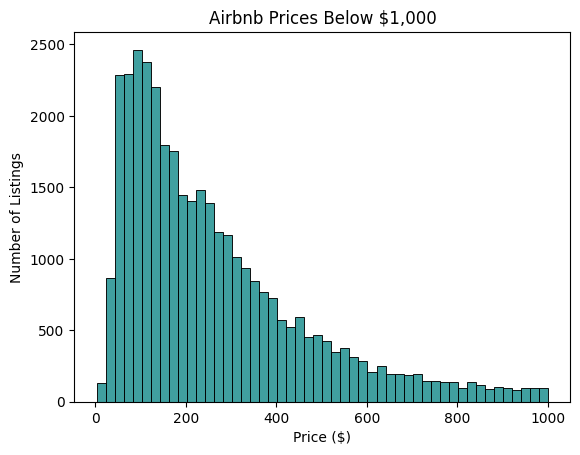

In [13]:
# Step 5: Convert and clean data types

# Check the original price data type
print("Before:", df['price'].dtype)

# Remove dollar signs and commas, then convert to numeric
df['price'] = df['price'].astype(str).str.replace(r'[$,]', '', regex=True)
df['price'] = pd.to_numeric(df['price'], errors='coerce')

# Check the new data type and summarize prices
print("After:", df['price'].dtype)
display(df['price'].describe())

# Plot prices below $1,000 for readability; keep all prices in the dataset
sns.histplot(df.loc[df['price'] < 1000, 'price'], bins=50, color='teal')
plt.title('Airbnb Prices Below $1,000')
plt.xlabel('Price ($)')
plt.ylabel('Number of Listings')
plt.show()

### Reflection:
1. What column did you fix?
2. What cleaning steps did you apply?
3. How does this help prepare the data for later use?

### ✍️ Your Response: 🔧
1. **What column did you fix?**
   - I fixed price, which was stored as text because it contained dollar signs and commas.

2. **What cleaning steps did you apply?**
   - I converted the values to strings, removed dollar signs and commas, and used pd.to_numeric() to convert them to numbers. With errors='coerce', values that could not be converted became NaN

3. **How does this help prepare the data for later use?**
   - Converting price to a numeric format allows us to calculate summary statistics, create price charts, and use price in regression or machine learning models without errors caused by text formatting.

## 6. Remove Duplicate Records

### Business framing:  

If a listing appears twice, it could inflate revenue estimates or confuse users. Airbnb needs each listing to be unique and accurate.

### Do the following:
- Check for rows that are exact duplicates
- If your data has an ID column and each ID is supposed to unique, then make sure there are no duplicate IDs
- Remove duplicates if found

In [15]:
# Check for exact duplicate rows and duplicate listing IDs
print("Duplicate rows:", df.duplicated().sum())
print("Duplicate IDs:", df['id'].duplicated().sum())

# Remove exact duplicates, then keep the first listing for each ID
df = df.drop_duplicates()
df = df.drop_duplicates(subset='id', keep='first')

# Confirm no duplicates remain
print("Remaining duplicate rows:", df.duplicated().sum())
print("Remaining duplicate IDs:", df['id'].duplicated().sum())

Duplicate rows: 0
Duplicate IDs: 0
Remaining duplicate rows: 0
Remaining duplicate IDs: 0


### Reflection:
1. Did you find duplicates?
2. How did you decide what to drop or keep?
3. Why are duplicates risky for Airbnb teams?

### ✍️ Your Response: 🔧 🔧
1. **Did you find duplicates?**
   - No, both the exact duplicate row count and duplicate listing ID count were 0.

2. **How did you decide what to drop or keep?**
   - No rows were dropped because no duplicates were found. If duplicates existed, the code would keep the first record for each listing ID and remove the others.

3. **Why are duplicates risky for Airbnb teams?**
   - Duplicates can inflate listing counts, booking capacity, and revenue estimates, leading to inaccurate reports and business decisions. Duplicate records in this analysis file would not necessarily cause repeated listings or double bookings on Airbnb itself.

## 7. Export Cleaned Data

Before wrapping up, export your cleaned Airbnb dataset to a CSV file. You'll need this file for **Assignment 7**, where you'll perform data transformation techniques.

### Do the following:
Make sure your data has:
- Cleaned and consistent column values
- Proper data types for each column
- Any unnecessary columns removed

This file should be the version of your dataset that you’d feel confident sharing with a teammate or using for deeper analysis.



```
# Explanation:
# - "cleaned_airbnb_data_6.csv" is the name of the file that will be saved
# - index=False prevents pandas from writing row numbers into the CSV
# - The file will be saved to your working directory (in Colab, you'll need to download it manually. Once you see the data in your files tab, just click on the three dots, then click “download”)
# - YOU MAY NEED TO PRESS “RUN” MULTIPLE TIMES IN ORDER FOR IT TO SHOW UP
# - FOR SOME DEVICES, IT MAY TAKE A FEW MINUTES BEFORE YOUR FILE SHOWS UP

```





In [18]:
# Save the cleaned dataset without row numbers
df.to_csv('cleaned_airbnb_data_6.csv', index=False)

# Confirm export and final dataset size
print("Saved as cleaned_airbnb_data_6.csv")
print("Rows:", df.shape[0], "| Columns:", df.shape[1])

Saved as cleaned_airbnb_data_6.csv
Rows: 43751 | Columns: 87


## 8. Final Reflection

You’ve just cleaned a real-world Airbnb dataset — the kind of work that happens every day in analyst and data science roles.

Before you move on to data transformation in Assignment 7, take a few moments to reflect on the decisions you made and what you learned.

### Reflection:
1. Which section of the assignment was the most challenging for you? What made it challenging? Was it the coding or the application of class concepts?
2. Look back at your assignment and discuss a time when you had to drop, fix, or keep a piece of data. Why was it necessary to drop, fix, or keep that specific piece of data? (e.x. dropping a column full of null values because it has no useful information)
3. What’s one way a business team (e.g., hosts, pricing analysts, app administrators) might benefit from the cleaned version of this data?
4. If you had more time, what would you explore or clean further?
5. How does this relate to your customized learning outcome you created in canvas?


Write your response clearly in full sentences. No more than a few sentences required per response.


### ✍️ Your Response: 🔧

1. **Which section of the assignment was the most challenging for you? What made it challenging? Was it the coding or the application of class concepts?**  
   Filling missing values was the most challenging because I had to decide which method made sense for each column. Applying class concepts, such as choosing the median for ratings and a placeholder for descriptions, was harder than writing the code.

2. **Look back at your assignment and discuss a time when you had to drop, fix, or keep a piece of data. Why was it necessary to drop, fix, or keep that specific piece of data?**  
   I dropped neighborhood_overview, host_since, and calendar_updated because they were completely empty. Removing them made the dataset easier to work with without losing any recorded information.

3. **What’s one way a business team (e.g., hosts, pricing analysts, app administrators) might benefit from the cleaned version of this data?**  
   Pricing analysts could use the numeric price column to calculate average prices, compare neighborhoods, and build pricing models. This could help them recommend competitive rates for hosts.

4. **If you had more time, what would you explore or clean further?**  
   I would investigate missing values in license to determine whether they indicate an unlicensed listing or unavailable information. I would also explore text descriptions and organize them into categories to better understand host profiles.

5. **How does this relate to your customized learning outcome you created in canvas?**  
   My learning outcome was to use Python to visualize large datasets in ways others could understand. Cleaning the data helped prepare it for analysis, while the charts made missing values and price patterns easier to see.

## Submission Instructions
✅ Checklist:
- All code cells run without error
- All markdown responses are complete
- Submit on Canvas as instructed

In [19]:
!jupyter nbconvert --to html "assignment_06_data_cleaning.ipynb"

[NbConvertApp] Converting notebook assignment_06_data_cleaning.ipynb to html
[NbConvertApp] WARNING | Alternative text is missing on 2 image(s).
[NbConvertApp] Writing 439175 bytes to assignment_06_data_cleaning.html
